Agentic RAG Jurídico (Portugal) com LangGraph + LlamaIndex

## Visão Geral
Este notebook implementa um pipeline **RAG “production-grade”** para QA jurídico sobre legislação portuguesa (SRIJ / jogos e apostas online), combinando:

- **Indexação por Artigo** (chunks ao nível de “Artigo N.º …”) com metadados (`artigo`, `jurisdiction`, `source`).
- **Retrieval híbrido** (Vector + BM25) e **lookup determinístico** quando a pergunta menciona explicitamente “Artigo N”.
- **Orquestração agentic com LangGraph**:
  1. *Domain Gate* (fora do domínio vs. potencialmente documental)
  2. *Retrieval Decider* (LLM decide se precisa de consultar a base documental)
  3. *Retrieval Tool* (lookup por artigo / hybrid fallback)
  4. *Chunk Grading* (filtra contexto aplicável; inclui bypass para “lookup textual”)
  5. *Answer Generation* (resposta fundamentada no contexto)
  6. *Reflection* (auto-verificação e correção quando há afirmações não suportadas)

## Objetivo do Grafo
Garantir respostas:
- **Fundamentadas** (grounded) quando a pergunta é documental/jurídica;
- **Diretas** quando a pergunta é conversacional (ex.: “Olá, como estás?”);
- **Robustas** para perguntas de *lookup* (ex.: “Qual é a redação da alínea g) do artigo 56.º?”) e perguntas temáticas (ex.: “autoexclusão”).

## LlangChain Graph
![Workflow Graph](output.png)

---

In [1]:
# Core imports
import re
import os
import warnings
warnings.filterwarnings('ignore')

# LlamaIndex imports
from llama_index.core import (
    VectorStoreIndex,
    Settings,
)
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
# BM25 retriever (LlamaIndex)
from llama_index.retrievers.bm25 import BM25Retriever  # requer o módulo bm25 estar disponível
from llama_index.core import SimpleDirectoryReader
from llama_index.readers.file import PyMuPDFReader
from llama_index.core.schema import TextNode
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.retrievers import QueryFusionRetriever

# LangGraph imports
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
#from langgraph.checkpoint.memory import MemorySaver

# LangChain imports
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

# Pydantic para structured outputs
from pydantic import BaseModel, Field
from typing import Literal

print("✅ All imports successful!")

2025-12-21 20:24:21.248645: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ All imports successful!


In [36]:
import dotenv
from pathlib import Path

DOT_ENV_PATH = Path.cwd().parent / ".env"

# Carregar o ficheiro .env file se existir
if DOT_ENV_PATH.exists():
    dotenv.load_dotenv(DOT_ENV_PATH)
    print(f"🔄 Loaded environment from: {DOT_ENV_PATH}")
else:
    print(f"⚠️ .env file not found at: {DOT_ENV_PATH}. Continuing...")

# Configuração do vLLLM
os.environ.setdefault("VLLM_MODEL_NAME", "openai/gpt-oss-20b")

# Configuração do LangSmith (Tier Gratuita)
os.environ.setdefault("LANGSMITH_ENDPOINT", "https://eu.api.smith.langchain.com")
os.environ.setdefault("LANGSMITH_TRACING", "true")
os.environ.setdefault("LANGSMITH_PROJECT", "Agentic-AI-Legal-SRIJ")

# Variáveis de ambiente necessárias
REQUIRED_ENV_VARS = {
    "VLLM_BASE_URL",
    "VLLM_API_KEY",
    "LANGSMITH_API_KEY",
}

print("\n🔍 Validating required environment variables...\n")

missing = []
for var in REQUIRED_ENV_VARS:
    value = os.getenv(var)
    if value is None or value.strip() == "":
        print(f"❌ Missing: {var}")
        missing.append(var)
    else:
        print(f"✅ {var} = {value[:4]}**** (loaded)")

if missing:
    print("\n❗ ERROR: Missing required environment variables:")
    for var in missing:
        print(f"   - {var}")
    print("\n💡 Fix: Add them to your .env file or your environment before running this script.")

print("\n🎉 All required environment variables are set correctly!")


# Configurar o modelo de embeddings (gratuito, local)
embed_model = HuggingFaceEmbedding(
    model_name="intfloat/multilingual-e5-large"
)
Settings.embed_model = embed_model

# Configurar o LLM
# Conectar ao vLLM server (Compatível com OpenAI)
llm = ChatOpenAI(
    base_url=os.getenv("VLLM_BASE_URL"),
    api_key=os.getenv("VLLM_API_KEY"),
    model=os.getenv("VLLM_MODEL_NAME"),
    temperature=0.0,
)

print("✅ Connected to vLLM server")

print("✅ Configuration complete!")
print(f"Embedding model: {embed_model.model_name}")
print(f"LLM: {llm.model_name}")

2025-12-21 21:10:24,072 - INFO - Load pretrained SentenceTransformer: intfloat/multilingual-e5-large


🔄 Loaded environment from: /home/sagemaker-user/agentic-ai-course-main/agentic-ai-course-main/.env

🔍 Validating required environment variables...

✅ VLLM_BASE_URL = http**** (loaded)
✅ VLLM_API_KEY = <VLL**** (loaded)
✅ LANGSMITH_API_KEY = lsv2**** (loaded)

🎉 All required environment variables are set correctly!
✅ Connected to vLLM server
✅ Configuration complete!
Embedding model: intfloat/multilingual-e5-large
LLM: openai/gpt-oss-20b


---

##  Step 1: Carregar PDFs e aplicar metadados

Nesta etapa:
- Carregamos os PDFs a partir de uma pasta (`SRIJ_docs/`) usando `PyMuPDFReader` para minimizar problemas de extração.
- Normalizamos metadados por documento (ex.: `source`, `version`, `doc_type`, `jurisdiction`).

Objetivo: preparar os documentos com metadados consistentes antes de criar a base de conhecimento.

In [10]:
# Definir o diretório dos PDF's
pdf_directory = "SRIJ_docs/"  # Pasta com os documentos

# Carregar os PDFs através do diretório, com PyMuPDFReader para evitar texto corrompido
reader = SimpleDirectoryReader(
    input_dir=pdf_directory,
    required_exts=[".pdf"],
    file_extractor={".pdf": PyMuPDFReader()}  # <-- Esta linha força o uso do PyMuPDF (resolve o problema de caracteres estranhos)
)
documents = reader.load_data()

# Processamento para adicionar custom metadata
metadata_mapping = {
    "Consolidacao_Decreto_Lei_n_66_2015_Diário da República_n_83_2015_0.pdf": {
        "source": "Regime Jurídico dos Jogos e Apostas Online ",
        "version": "7.0",
        "doc_type": "Lei Geral",
        "classification": "Público",
        "jurisdiction": "PT"
    },
    "Regulamento_n_836_2015_Regras_Registo_Conta_Jogador.pdf": {
        "source": "Regulamento nº 836/2015",
        "version": "1.0",
        "doc_type": "Regulamento",
        "classification": "Público",
        "jurisdiction": "PT"
    }
}

# Aplicar custom metadata para cada 1 dos documentos carregados
for doc in documents:
    filename = doc.metadata.get("file_name")
    if filename in metadata_mapping:
        doc.metadata.update(metadata_mapping[filename])
    else:
        doc.metadata.update({
            "source": filename.replace(".pdf", "") if filename else "unknown",
            "version": "1.0",
            "doc_type": "unknown",
            "jurisdiction": "PT"
        })

print(f"✅ Loaded {len(documents)} documents.")
for i, doc in enumerate(documents, 1):
    print(f"{i}. {doc.metadata.get('source')} | chars={len(doc.text):,}")

✅ Loaded 63 documents.
1. Regime Jurídico dos Jogos e Apostas Online  | chars=1,889
2. Regime Jurídico dos Jogos e Apostas Online  | chars=2,155
3. Regime Jurídico dos Jogos e Apostas Online  | chars=2,114
4. Regime Jurídico dos Jogos e Apostas Online  | chars=755
5. Regime Jurídico dos Jogos e Apostas Online  | chars=5,023
6. Regime Jurídico dos Jogos e Apostas Online  | chars=5,256
7. Regime Jurídico dos Jogos e Apostas Online  | chars=3,081
8. Regime Jurídico dos Jogos e Apostas Online  | chars=2,006
9. Regime Jurídico dos Jogos e Apostas Online  | chars=3,967
10. Regime Jurídico dos Jogos e Apostas Online  | chars=4,297
11. Regime Jurídico dos Jogos e Apostas Online  | chars=2,640
12. Regime Jurídico dos Jogos e Apostas Online  | chars=3,356
13. Regime Jurídico dos Jogos e Apostas Online  | chars=1,868
14. Regime Jurídico dos Jogos e Apostas Online  | chars=3,294
15. Regime Jurídico dos Jogos e Apostas Online  | chars=4,861
16. Regime Jurídico dos Jogos e Apostas Online  | chars=3,

---

## Step 2: Pré-processamento e criação de nós por Artigo

Nesta etapa:
- Limpamos artefactos comuns de PDFs (ex.: “28 de 59”, cabeçalhos recorrentes).
- Fazemos *chunking* ao nível de **Artigo** (cada nó corresponde a “Artigo N.º …”).
- Extraímos `artigo` e guardamos em metadata para suportar *lookup* determinístico.

Objetivo: maximizar precisão em perguntas do tipo “Artigo X / alínea Y”, reduzindo ruído no retrieval.

In [11]:
# Limpar os PDF's
def clean_legal_text(t: str) -> str:
    # remove "28 de 59" and similar
    t = re.sub(r"(?m)^\s*\d+\s+de\s+\d+\s*$", "", t)
    # remove "Pág. 36 de 59"
    t = re.sub(r"(?m)^\s*Pág\.\s*\d+\s+de\s+\d+\s*$", "", t)
    # (opcional) remover linhas muito comuns de cabeçalhos
    t = re.sub(r"(?m)^\s*Diário da República.*$", "", t)
    t = re.sub(r"(?m)^\s*DRE\s*$", "", t)
    t = re.sub(r"\n{3,}", "\n\n", t)
    return t.strip()

In [12]:
#Separar por artigo
def split_by_artigo(text: str) -> list[str]:
    # split mantendo "Artigo N.º" no início
    parts = re.split(r"(?m)(?=^\s*Artigo\s+\d+\.\s*º|^\s*Artigo\s+\d+\.º|^\s*Artigo\s+\d+º)", text)
    return [p.strip() for p in parts if p.strip()]

def extract_artigo_num(chunk: str) -> str | None:
    # cobre variações: "Artigo 56.º" / "Artigo 56º" / "Artigo 56. º"
    m = re.search(r"(?mi)^\s*Artigo\s+(\d+)\s*(?:\.?\s*º|º)?", chunk)
    return m.group(1) if m else None

nodes: list[TextNode] = []
for doc in documents:
    cleaned = clean_legal_text(doc.text)  # <-- limpa aqui (sem tentar alterar doc)
    for art_chunk in split_by_artigo(cleaned):
        artigo = extract_artigo_num(art_chunk)
        md = dict(doc.metadata)
        if artigo:
            md["artigo"] = artigo
        nodes.append(TextNode(text=art_chunk, metadata=md))

print(f"✅ Created {len(nodes)} article-level nodes.")


from collections import defaultdict

ARTIGO_TO_NODES = defaultdict(list)
for idx, n in enumerate(nodes):
    art = (n.metadata or {}).get("artigo")
    if art:
        ARTIGO_TO_NODES[str(art)].append(idx)

print(f"✅ Built ARTIGO_TO_NODES for {len(ARTIGO_TO_NODES)} artigos.")

index = VectorStoreIndex(nodes, show_progress=True)
index.storage_context.persist("./SRIJ_docs_index")

✅ Created 335 article-level nodes.
✅ Built ARTIGO_TO_NODES for 93 artigos.


Generating embeddings:   0%|          | 0/335 [00:00<?, ?it/s]

---

## Step 3: Criar Retrieval Tool (lookup por Artigo + hybrid BM25/Vector)

Nesta etapa:
- Construímos um índice vetorial (`VectorStoreIndex`) sobre os nós.
- Construímos um retriever **BM25** sobre os mesmos nós.
- Implementamos um **hybrid retrieval** manual (combinação de scores normalizados).
- Implementamos um **lookup determinístico** quando a query contém “Artigo N” (filtra diretamente por `metadata["artigo"]`).

Objetivo: melhorar recall e precisão em QA jurídico, incluindo:
- perguntas com referência explícita a artigos (lookup determinístico),
- perguntas temáticas sem referência a artigo (hybrid BM25 + vector).

In [13]:
TOP_K = 12

vector_ret = VectorIndexRetriever(index=index, similarity_top_k=TOP_K)
bm25_ret = BM25Retriever.from_defaults(nodes=nodes, similarity_top_k=TOP_K)

def hybrid_retrieve(query: str, top_k: int = TOP_K):
    """
    Hybrid deterministico: BM25 + Vector.
    - Sem LLM
    - Sem OpenAI
    - Junta resultados e reordena por score normalizado simples
    """
    v = vector_ret.retrieve(query) or []
    b = bm25_ret.retrieve(query) or []

    # Deduplicação: usa id do node se existir, senão hash do texto
    def node_key(item):
        node = getattr(item, "node", item)
        node_id = getattr(node, "node_id", None)
        if node_id:
            return ("id", node_id)
        return ("text", hash(node.text))

    merged = {}
    # Guardamos score por origem
    for item in v:
        node = getattr(item, "node", item)
        k = node_key(item)
        merged.setdefault(k, {"node": node, "vector": None, "bm25": None})
        merged[k]["vector"] = float(getattr(item, "score", 0.0) or 0.0)

    for item in b:
        node = getattr(item, "node", item)
        k = node_key(item)
        merged.setdefault(k, {"node": node, "vector": None, "bm25": None})
        merged[k]["bm25"] = float(getattr(item, "score", 0.0) or 0.0)

    if not merged:
        # Sem resultados, devolve lista vazia controlada (não crasha)
        return []

    # Normalização simples para combinar (evita depender de escalas diferentes)
    vec_scores = [m["vector"] for m in merged.values() if m["vector"] is not None]
    bm_scores  = [m["bm25"] for m in merged.values() if m["bm25"] is not None]

    vec_max = max(vec_scores) if vec_scores else 1.0
    bm_max  = max(bm_scores) if bm_scores  else 1.0

    ranked = []
    for m in merged.values():
        v_norm = (m["vector"] / vec_max) if m["vector"] is not None else 0.0
        b_norm = (m["bm25"] / bm_max)     if m["bm25"] is not None else 0.0
        fused = 0.5 * v_norm + 0.5 * b_norm
        ranked.append((fused, {"node": m["node"], "vector": m["vector"], "bm25": m["bm25"], "mode": "hybrid"}))

    ranked.sort(key=lambda x: x[0], reverse=True)
    return ranked[:top_k]

print("✅ Hybrid retriever pronto (manual BM25 + Vector, sem LLM).")


2025-12-21 20:36:35,069 - DEBUG - Building index from IDs objects


✅ Hybrid retriever pronto (manual BM25 + Vector, sem LLM).


In [14]:
# Criação da tool
@tool
def retrieve_gambling_law_docs(query: str) -> str:
    """
    Recupera excertos do(s) diploma(s) na base de conhecimento.
    Estratégia:
      - Se detectar 'Artigo N' na query -> lookup determinístico por metadata["artigo"]
      - Caso contrário -> hybrid BM25 + Vector (sem LLM)
    """
    try:
        # ----------------------------
        # 1) Deterministico artigo lookup
        # ----------------------------
        m = re.search(r"(?i)\bartigo\s+(\d+)", query)
        if m:
            art_num = m.group(1)
            idxs = ARTIGO_TO_NODES.get(str(art_num), [])
            if idxs:
                # cria um "ranked" compatível com o formato de output
                ranked = []
                for i in idxs[:TOP_K]:
                    n = nodes[i]
                    ranked.append((1.0, {"node": n, "vector": None, "bm25": None, "mode": "deterministic"}))

                return _format_ranked_chunks(ranked)

        # ----------------------------
        # 2) Hybrid fallback
        # ----------------------------
        ranked = hybrid_retrieve(query, top_k=TOP_K)
        return _format_ranked_chunks(ranked)

    except Exception as e:
        # IMPORTANTE: não devolver stack trace como "contexto"
        print(f"[retrieve_gambling_law_docs] ERROR: {repr(e)}")
        return "ERRO_INTERNO_RETRIEVE: ocorreu um erro ao recuperar contexto do documento. Tenta novamente."

def _format_ranked_chunks(ranked):
    """
    ranked: list[ (fused_score, {"node": TextNode, "vector": float|None, "bm25": float|None, ...}) ]
    """
    context_parts = []
    for i, (fused, m) in enumerate(ranked, 1):
        node = m["node"]
        md = (node.metadata or {})
        source = md.get("source", "unknown")
        artigo = md.get("artigo", None)

        v = m.get("vector", None)
        b = m.get("bm25", None)
        mode = m.get("mode", "hybrid")

        header = f"[Chunk {i} | mode={mode} | fused={fused:.3f} | v={v} | bm25={b} | source={source}"
        if artigo:
            header += f" | artigo={artigo}"
        header += "]"

        context_parts.append(f"{header}\n{node.text}\n")

    return "\n---\n".join(context_parts)

tools = [retrieve_gambling_law_docs]

print("✅ Retrieval tool created!")
print(f"Tool name: {tools[0].name}")
print(f"Tool description: {tools[0].description}")

✅ Retrieval tool created!
Tool name: retrieve_gambling_law_docs
Tool description: Recupera excertos do(s) diploma(s) na base de conhecimento.
Estratégia:
  - Se detectar 'Artigo N' na query -> lookup determinístico por metadata["artigo"]
  - Caso contrário -> hybrid BM25 + Vector (sem LLM)


---

## Step 4: Construir o Agentic RAG Graph com LangGraph

Workflow implementado:

1. **Domain Gate**  
   Classifica se a pergunta está *fora_do_dominio* (conversa casual) ou é *potencialmente_documental*.

2. **Retrieval Decider (LLM + Tools)**  
   Decide se deve chamar a tool de retrieval (`retrieve_gambling_law_docs`) ou responder diretamente.

3. **Retrieval Tool (ToolNode)**  
   Executa retrieval (lookup por artigo / hybrid BM25+Vector) e devolve chunks com cabeçalhos e metadados.

4. **Chunk Grading (chunk-level)**  
   Seleciona quais os chunks aplicáveis. Inclui um **bypass para perguntas de “lookup textual”** (ex.: “redação / o que diz / dispõe” + “artigo”), para não rejeitar o artigo correto por heurísticas de “aplicabilidade”.

5. **Answer Generation (grounded)**  
   Gera resposta em português, **apenas** com base no contexto selecionado; inclui prompt específico para pedidos de **alíneas**.

6. **Reflection (self-check)**  
   Verifica se a resposta contém afirmações não suportadas e gera uma versão corrigida (ou “não contém informação suficiente”).

### 4.1 Definir State

In [15]:
# MessagesState personalizado

from langgraph.graph import MessagesState
from typing import List, Optional
from pydantic import Field

class CustomMessagesState(MessagesState):
    domain_label: Optional[str] = None
    applicable_indices: List[int] = Field(default_factory=list)
    graded_info: List[dict] = Field(default_factory=list)

print("✅ A utilizar CustomMessagesState para gestão do state do graph")

✅ A utilizar CustomMessagesState para gestão do state do graph


### 4.2 Node: Domain Gate

In [16]:
# --- Domain gate: decide se a pergunta é conversacional ou potencialmente documental ---
def domain_gate(state: CustomMessagesState) -> dict:
    """
    Classifica a mensagem do utilizador como:
    - 'fora_do_dominio' (conversa casual / fora do domínio jurídico)
    - 'potencialmente_documental' (assuntos sobre jogos/apostas/legislação)
    """
    print("\n🔎 Node: domain_gate")
    messages = state["messages"]
    question = messages[0].content

    DOMAIN_PROMPT = f"""
Classifica a seguinte mensagem.

Mensagem:
{question}

Classificação:
- 'fora_do_dominio' para saudações, conversa casual, perguntas pessoais, técnicas ou filosóficas não relacionadas com legislação sobre jogos ou apostas.
- 'potencialmente_documental' para qualquer pergunta que possa ser respondida com base em legislação, regulamentos, jurisprudência ou documentos sobre jogos/apostas.

Responde APENAS com:
fora_do_dominio
ou
potencialmente_documental
"""

    response = llm.invoke([{"role": "user", "content": DOMAIN_PROMPT}])
    label = response.content.strip().lower()
    print(f"   Domain gate result: {label}")

    return {"domain_label": label}

print("✅ Node 1 definido: domain_gate")

✅ Node 1 definido: domain_gate


### 4.3 Node: Retrieval Decider (LLM decide chamar a tool)

In [17]:
from langchain_core.messages import AIMessage

def retrieval_decider(state: CustomMessagesState) -> dict:
    question = state["messages"][0].content

    PROMPT = f"""
Responde à pergunta do utilizador.
Se precisares de consultar o documento legal, usa a tool `retrieve_gambling_law_docs`.
Caso contrário, responde diretamente.

Pergunta:
{question}
"""

    llm_with_tools = llm.bind_tools(tools)
    response = llm_with_tools.invoke(
        [HumanMessage(content=PROMPT)]
    )

    #print("   Response type:", type(response))
    #print("   Has tool_calls:", hasattr(response, "tool_calls"))
    #print("   tool_calls:", getattr(response, "tool_calls", None))
    #print("   Response content (text):", response.content)

    return {"messages": [response]}

print("✅ Node 2 defined: LLLM que decide")

✅ Node 2 defined: LLLM que decide


### 4.4 Node: Resposta fora do domínio (direct_chat_response)

In [18]:
def direct_chat_response(state: CustomMessagesState) -> dict:
    print("\n💬 Node: direct_chat_response")
    question = state["messages"][0].content

    PROMPT = f"""
Responde de forma educada e natural em português. Esta pergunta não está relacionada com legislação de jogos ou apostas.
Pergunta: {question}

Resposta:
"""
    response = llm.invoke([{"role": "user", "content": PROMPT}])
    return {"messages": [response]}

print("✅ Node 3 defined: resposta fora do domínio")

✅ Node 3 defined: resposta fora do domínio


### 4.3 Node: Retrieval (ToolNode)

In [19]:
# ToolNode executa automáticamente tools do AIMessage.tool_calls
tools_node = ToolNode(tools)

print("✅ Node 4 defined: retrieve (ToolNode)")

✅ Node 4 defined: retrieve (ToolNode)


### 4.6 Node: Chunk Grading (chunk-level)

In [20]:
from pydantic import BaseModel
from typing import List

#class ChunkGrade(BaseModel):
#    index: int
#    applicable: Literal["yes", "no"]
#    reason: str

# We'll use the LLM repeatedly for each chunk (small overhead but deterministic with temp=0.0)
def grade_chunks(state: CustomMessagesState) -> dict:
    print("\n🧾 Node: grade_chunks (chunk-level grading)")
    messages = state["messages"]
    question = messages[0].content

    tool_messages = [m for m in messages if isinstance(m, ToolMessage)]
    #print("   Tool messages count:", len(tool_messages))
    if not tool_messages:
        print("   ⚠️ Retrieve não encontrado.")
        return {"índices aplicáveis": []}

    # Retrieved text is expected to be joined by "\n---\n" as in retrieve_gambling_law_docs
    retrieved = tool_messages[-1].content
    chunks = retrieved.split("\n---\n")
    #print("   Retrieved chars:", len(retrieved))
    #print("   Chunks count:", len(chunks))
    #print("   First chunk preview (300 chars):")
    #print(chunks[0][:300] if chunks else "   <no chunks>")
    applicable_indices = []
    graded_info = []

    # =========================
    # Lookup textual bypass: perguntas do tipo "qual a redação / o que diz"
    # =========================
    is_lookup_textual = bool(re.search(r"(?i)\b(redação|texto|o que diz|dispõe)\b", question)) and bool(re.search(r"(?i)\bartigo\b", question))
    
    if is_lookup_textual:
        print("   Pergunta de LOOKUP TEXTUAL detetada -> bypass 'aplicabilidade' grading")
    
        # 1) Tenta detetar Artigo N na pergunta
        m_art = re.search(r"(?i)\bartigo\s+(\d+)", question)
        target_art = m_art.group(1) if m_art else None
    
        # 2) Tenta detetar alínea (g), a), etc.)
        m_al = re.search(r"(?i)\bal[ií]nea\s+([a-z])\)", question)
        alvo_alinea = m_al.group(1).lower() if m_al else None
    
        applicable_indices = []
        graded_info = []
    
        for i, chunk in enumerate(chunks):
            # Preferência: filtra por artigo usando o header (artigo=56)
            if target_art and (f"artigo={target_art}" not in chunk.lower()):
                graded_info.append({"index": i, "applicable": "no", "reason": f"lookup: não é artigo {target_art}"})
                continue
    
            # Se pedem alínea, tenta localizar no texto do chunk (flexível)
            if alvo_alinea:
                # procura padrões comuns de alínea: "g)" "g )" "(g)" "g -"
                patt = rf"(?i)(^|\s|\n)\(?{re.escape(alvo_alinea)}\s*\)?\s*[\)\-:]"
                if re.search(patt, chunk):
                    applicable_indices.append(i)
                    graded_info.append({"index": i, "applicable": "yes", "reason": f"lookup: contém marcador de alínea {alvo_alinea}"})
                else:
                    # aqui vem a mudança importante:
                    # mesmo não encontrando o marcador, se é o artigo certo, mantemos aplicável
                    applicable_indices.append(i)
                    graded_info.append({"index": i, "applicable": "yes", "reason": f"lookup: artigo {target_art} (alínea {alvo_alinea} não localizada por padrão, mas mantém-se o artigo)"})
            else:
                applicable_indices.append(i)
                graded_info.append({"index": i, "applicable": "yes", "reason": f"lookup: artigo {target_art or 'n/d'}"})
    
        print("   Applicable indices (lookup):", applicable_indices)
        return {"applicable_indices": applicable_indices, "graded_info": graded_info}



    CHUNK_PROMPT_TEMPLATE = """
Você é um advogado que avalia se o trecho legal abaixo se aplica à pergunta do utilizador.

Pergunta:
{question}

Trecho legal:
{chunk}

Tarefa:
Responda APENAS com 'yes' ou 'no' indicando se o trecho contém uma norma aplicável à situação descrita na pergunta, entendendo por aplicável que:
- o trecho descreve ou regula o comportamento, OU
- o trecho qualifica juridicamente o comportamento (ex.: "constitui contraordenação", "é proibido", "está impedido", "tem direito a"), OU
- o trecho atribui consequências legais, obrigações legais ou responsabilidades legais relacionadas.

Depois de 'yes' ou 'no', escreva uma breve justificação (uma frase) em português sobre porquê.

Resposta (formato esperado):
yes
Justificação: ...
"""

    for i, chunk in enumerate(chunks):
        prompt = CHUNK_PROMPT_TEMPLATE.format(question=question, chunk=chunk[:2000])
        resp = llm.invoke([{"role": "user", "content": prompt}])
        text = resp.content.strip()
        # Interpret first line as yes/no, rest as reason
        lines = [l.strip() for l in text.splitlines() if l.strip()]
        if not lines:
            applicable = "no"
            reason = "sem resposta do modelo"
        else:
            first = lines[0].lower()
            applicable = "yes" if first.startswith("y") or first.startswith("s") else "no"  # aceita 'sim'/'yes'
            reason = " ".join(lines[1:]) if len(lines) > 1 else ""
            print(f"\n   --- Chunk {i} ---")
            print("   Aplicável:", applicable)
            print("   Razão:", reason[:200])
            #print("   Chunk preview (300 chars):")
            #print(chunk[:300])
        if applicable == "yes":
            applicable_indices.append(i)
        graded_info.append({"index": i, "applicable": applicable, "reason": reason})

    print("\n   Índices aplicáveis indices:", applicable_indices)
    print("   Contagem de Chunks:", len(graded_info))
    
    # Guardar metainformação opcional no estado para debugging
    return {"applicable_indices": applicable_indices, "graded_info": graded_info}

print("✅ Node 5 defined: grade chunks")

✅ Node 5 defined: grade chunks


### 4.7 Node: Answer Generation (grounded)

In [21]:
def generate_answer(state: CustomMessagesState) -> dict:
    print("\n🛠️ Node: generate_answer (grounded)")
    messages = state["messages"]
    question = messages[0].content

    # get retrieved chunks and graded indices
    tool_messages = [m for m in messages if isinstance(m, ToolMessage)]
    retrieved = tool_messages[-1].content if tool_messages else ""
    chunks = retrieved.split("\n---\n") if retrieved else []

    #print("   Tool context chars:", len(retrieved))
    #print("   Retrieved chunks:", len(chunks))
    #print("   Applicable indices:", state.get("applicable_indices", []))

    applicable_indices = state.get("applicable_indices", [])
    if not applicable_indices:
        # No applicable chunks -> explicit "não consta"
        msg = AIMessage(content="O documento analisado não contém uma norma que responda explicitamente à pergunta.")
        return {"messages": [msg]}

    # assemble context from applicable chunks (preserve order)
    selected = [chunks[i] for i in applicable_indices if i < len(chunks)]
    context = "\n---\n".join(selected)

    #if chunks:
        #print("   First retrieved chunk preview (300 chars):")
        #print(chunks[0][:300])

    is_lookup_textual = bool(re.search(r"(?i)\b(redação|texto|o que diz|dispõe)\b", question)) and bool(re.search(r"(?i)\bartigo\b", question))
    m_al = re.search(r"(?i)\bal[ií]nea\s+([a-z])\)", question)
    alvo_alinea = m_al.group(1).lower() if m_al else None
    
    if is_lookup_textual and alvo_alinea:
        GENERATE_PROMPT = f"""
    És um assistente jurídico. O utilizador pediu a REDAÇÃO exata de uma alínea.
    
    Regras:
    - Responde APENAS com a transcrição (ou citação fiel) da alínea pedida, tal como aparece no contexto.
    - Se a alínea pedida não estiver visível no contexto fornecido, diz explicitamente:
      "Nos excertos recuperados do Artigo, não aparece a alínea {alvo_alinea})."
      e devolve o trecho mais próximo (as alíneas imediatamente anteriores/posteriores, se existirem no contexto).
    - Não uses conhecimento externo.
    
    Pergunta:
    {question}
    
    Contexto:
    {context}
    
    Resposta:
    """
    else:
        GENERATE_PROMPT = f"""
    És um assistente especializado em legislação portuguesa de jogos e apostas online.
    
    Responda à pergunta APENAS com base no texto indicado em 'Contexto'.
    Não utilizes conhecimento externo. Não faças suposições.
    Se uma afirmação não estiver suportada pelo contexto, indique claramente que a informação não consta no documento.
    
    Pergunta:
    {question}
    
    Contexto:
    {context}
    
    Resposta (em português):
    """

    response = llm.invoke([{"role": "user", "content": GENERATE_PROMPT}])
    # Guardar resposta inicial para reflexão
    return {"messages": [response], "initial_answer": response.content}

print("✅ Node 7 defined: generate_answer")

✅ Node 7 defined: generate_answer


### 4.8 Node: Reflection (self-check)

In [22]:
def reflection_node(state: CustomMessagesState) -> dict:
    print("\n🪞 Node: Reflection (self-check)")
    messages = state["messages"]
    question = messages[0].content

    # initial answer is the last AI message
    ai_messages = [m for m in messages if isinstance(m, AIMessage)]
    if not ai_messages:
        return {"messages": [AIMessage(content="Sem resposta gerada.")]}

    initial = ai_messages[-1].content

    print("   Resposta inicial (500 chars):")
    print(initial[:500])

    # Retrieve the context again (selected chunks)
    tool_messages = [m for m in messages if isinstance(m, ToolMessage)]
    retrieved = tool_messages[-1].content if tool_messages else ""
    chunks = retrieved.split("\n---\n") if retrieved else []
    applicable_indices = state.get("applicable_indices", [])
    selected = [chunks[i] for i in applicable_indices if i < len(chunks)]
    context = "\n---\n".join(selected)

    #print("   Reflection context chars:", len(context))
    print("   Contexto da reflexão (500 chars):")
    print(context[:500] if context else "<EMPTY CONTEXT>")

    REFLECTION_PROMPT = f"""
Você é um revisor jurídico. Avalia a resposta abaixo e verifica se todas as afirmações factuais e conclusões jurídicas são sustentadas pelo contexto fornecido. 

Pergunta:
{question}

Contexto:
{context}

Resposta do assistente:
{initial}

Tarefa:
1) Indica SE a resposta contém afirmações que NÃO estão suportadas explicitamente pelo contexto. Responda apenas 'yes' ou 'no'.
2) Se respondeu 'yes', liste brevemente (1-2 frases) as afirmações não suportadas.
3) Se houver afirmações não suportadas, gere uma versão CORRIGIDA da resposta que apenas use o contexto. Se for impossível responder com o contexto, produza: "O documento não contém informação para responder a esta pergunta."

Responde em português, no formato JSON com campos:
- unsupported: "yes" ou "no"
- issues: texto breve ou "" 
- corrected_answer: texto
"""
    reflection_resp = llm.invoke([{"role": "user", "content": REFLECTION_PROMPT}])
    # tentamos extrair JSON-like output; mas para simplicidade guardamos retorno textualmente
    reflection_text = reflection_resp.content

    print("   Reflection raw output preview (500 chars):")
    print(reflection_text[:500])

    # If reflection suggests corrected answer, prefer it; otherwise keep initial
    # Very simple heuristic: if "O documento não contém informação suficiente" in reflection_text -> return that.
    if "O documento não contém informação suficiente" in reflection_text:
        final = AIMessage(content="O documento não contém informação suficiente para responder a esta pergunta.")
    else:
        # try to extract corrected_answer block heuristically
        if "corrected_answer:" in reflection_text.lower():
            # naive extraction
            parts = reflection_text.split("corrected_answer:")
            corrected = parts[-1].strip()
            final = AIMessage(content=corrected)
        else:
            # fallback: return initial answer but attach reflection note
            final = AIMessage(content=initial + "\n\n(Verificação automática concluída; verifique manualmente se necessário.)")

    return {"messages": [final]}

print("✅ Node 6 defined: reflection")

✅ Node 6 defined: reflection


### 4.9 Construir e compilar o Graph

In [23]:
# Build the corrected graph
workflow = StateGraph(CustomMessagesState)

# Add nodes: domain gate, retrieve (ToolNode), grade_chunks, generate_answer, reflection, direct_chat_response
workflow.add_node("domain_gate", domain_gate)
workflow.add_node("retrieval_decider", retrieval_decider)
workflow.add_node("retrieve", tools_node)
workflow.add_node("grade_chunks", grade_chunks)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("reflection", reflection_node)
workflow.add_node("direct_chat_response", direct_chat_response)

# Start -> domain gate
workflow.add_edge(START, "domain_gate")

# Após resposta direta acaba
workflow.add_edge("direct_chat_response", END)

# domain_gate -> use mapping (visível e seguro)
workflow.add_conditional_edges(
    "domain_gate",
    lambda state: state.get("domain_label"),
    {"fora_do_dominio": "direct_chat_response", "potencialmente_documental": "retrieval_decider"}
)

workflow.add_conditional_edges(
    "retrieval_decider",
    tools_condition,
    {
        "tools": "retrieve",              # se houver tool_calls
        END: "generate_answer"         # se NÃO houver tool_calls
    }
)

# After retrieval -> grade_chunks
workflow.add_edge("retrieve", "grade_chunks")

# After grading -> generate_answer
workflow.add_edge("grade_chunks", "generate_answer")

# After generate -> reflection
workflow.add_edge("generate_answer", "reflection")

# After reflection -> END
workflow.add_edge("reflection", END)

# Compilar grafo
graph = workflow.compile()

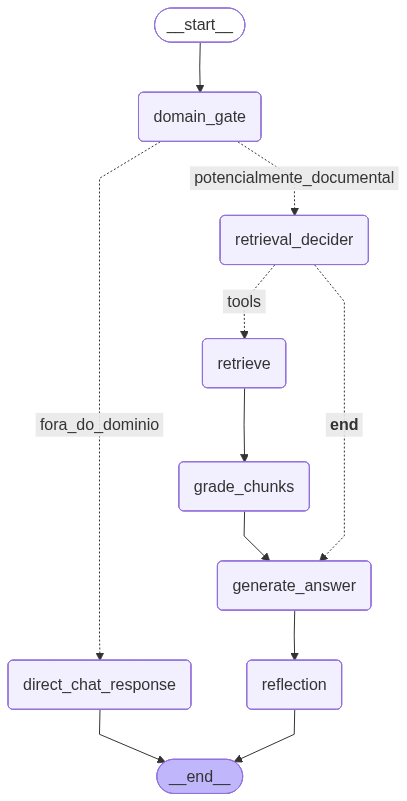

In [24]:
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

---

## Step 5: Testar o sistema (queries típicas)

### 5.1 Teste: Pergunta temática (deve recuperar e responder com base no documento)

In [39]:
# Test query that requires retrieval
test_query_1 = "Um jogador pode autoexcluir-se dos jogos e apostas online em Portugal? Qual o período mínimo de autoexclusão?"

print(f"Query: {test_query_1}")
print("="*70)

inputs = {"messages": [HumanMessage(content=test_query_1)]}

# Get final result
final_state = graph.invoke(inputs)
final_answer = final_state["messages"][-1].content

print("\n" + "="*70)
print("FINAL ANSWER:")
print(final_answer)
print("="*70)

Query: Um jogador pode autoexcluir-se dos jogos e apostas online em Portugal? Qual o período mínimo de autoexclusão?

🔎 Node: domain_gate


2025-12-21 21:20:18,818 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   Domain gate result: potencialmente_documental


2025-12-21 21:20:19,672 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"



🧾 Node: grade_chunks (chunk-level grading)


...


   --- Chunk 11 ---
   Aplicável: no
   Razão: Justificação: O trecho trata apenas da atribuição de licença a operadores, não menciona regras de autoexclusão para jogadores.

   Índices aplicáveis indices: [0, 1, 2, 3, 4, 5]
   Contagem de Chunks: 12

🛠️ Node: generate_answer (grounded)


2025-12-21 21:20:55,318 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"



🪞 Node: Reflection (self-check)
   Resposta inicial (500 chars):
**Sim.**  
O jogador tem o direito de auto‑excluir‑se diretamente no sítio na Internet da entidade de controlo, inspeção e regulação, ficando impedido de jogar nos sítios na Internet de todas as entidades exploradoras.  

**Período mínimo de autoexclusão**  
O período de autoexclusão tem a duração mínima de **três meses** e perdura até à data indicada pelo jogador ou, na falta dessa indicação, por tempo indeterminado.  

*(Contexto: Chunk 1 – “O período de autoexclusão tem a duração mínima de tr
   Contexto da reflexão (500 chars):
[Chunk 1 | mode=hybrid | fused=1.000 | v=0.8737304568119402 | bm25=3.755406618118286 | source=Regime Jurídico dos Jogos e Apostas Online ]
período por si indicado. 
3 - O jogador tem, ainda, o direito a autoexcluir-se diretamente no sítio na Internet da entidade de controlo, inspeção e 
regulação, ficando, neste caso, impedido de jogar nos sítios na Internet de todas as entidades exploradoras.

2025-12-21 21:21:02,323 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   Reflection raw output preview (500 chars):
{"unsupported":"no","issues":"","corrected_answer":"Sim. O jogador tem o direito de auto‑excluir‑se diretamente no sítio na Internet da entidade de controlo, inspeção e regulação, ficando impedido de jogar nos sítios na Internet de todas as entidades exploradoras. Período mínimo de autoexclusão: O período de autoexclusão tem a duração mínima de três meses e perdura até à data indicada pelo jogador ou, na falta dessa indicação, por tempo indeterminado."}

FINAL ANSWER:
**Sim.**  
O jogador tem o direito de auto‑excluir‑se diretamente no sítio na Internet da entidade de controlo, inspeção e regulação, ficando impedido de jogar nos sítios na Internet de todas as entidades exploradoras.  

**Período mínimo de autoexclusão**  
O período de autoexclusão tem a duração mínima de **três meses** e perdura até à data indicada pelo jogador ou, na falta dessa indicação, por tempo indeterminado.  

*(Contexto: Chunk 1 – “O período de autoexclusão tem a d

---
### 5.2 Teste: Pergunta direta sobre alínea (deve recuperar e responder com base no documento fazendo bypass ao grading de aplicabilidade e utilizando o lookup)

In [38]:
# Test query that requires retrieval
test_query_2 = "Qual é a redação alinea g) do artigo 56º do Decreto-Lei n.º 66/2015, de 29 de abril que aprova o regime juridico dos jogos e apostas online?"

print(f"Query: {test_query_2}")
print("="*70)

inputs = {"messages": [HumanMessage(content=test_query_2)]}

# Get final result
final_state = graph.invoke(inputs)
final_answer = final_state["messages"][-1].content

print("\n" + "="*70)
print("FINAL ANSWER:")
print(final_answer)
print("="*70)

Query: Qual é a redação alinea g) do artigo 56º do Decreto-Lei n.º 66/2015, de 29 de abril que aprova o regime juridico dos jogos e apostas online?

🔎 Node: domain_gate


2025-12-21 21:18:15,899 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   Domain gate result: potencialmente_documental


2025-12-21 21:18:17,245 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"



🧾 Node: grade_chunks (chunk-level grading)
   Pergunta de LOOKUP TEXTUAL detetada -> bypass 'aplicabilidade' grading
   Applicable indices (lookup): [0, 1]

🛠️ Node: generate_answer (grounded)


2025-12-21 21:18:18,769 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"



🪞 Node: Reflection (self-check)
   Resposta inicial (500 chars):
g) Não pagar ao jogador o prémio no valor anunciado;
   Contexto da reflexão (500 chars):
[Chunk 1 | mode=deterministic | fused=1.000 | v=None | bm25=None | source=Regime Jurídico dos Jogos e Apostas Online  | artigo=56]
Artigo 56.º
Contraordenações muito graves

---
[Chunk 2 | mode=deterministic | fused=1.000 | v=None | bm25=None | source=Regime Jurídico dos Jogos e Apostas Online  | artigo=56]
Artigo 56.º
Contraordenações muito graves
Constitui contraordenação muito grave, praticada pela entidade exploradora, punível com coima: 
a) Disponibilizar apostas desportivas à cota que inci


2025-12-21 21:18:20,673 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   Reflection raw output preview (500 chars):
{"unsupported":"no","issues":"","corrected_answer":"g) Não pagar ao jogador o prémio no valor anunciado;"}

FINAL ANSWER:
g) Não pagar ao jogador o prémio no valor anunciado;

(Verificação automática concluída; verifique manualmente se necessário.)


---
### 5.3 Teste: Pergunta temática cuja resposta se encontra exclusivamente numa alínea de um artigo (deve recuperar e responder com base nessa alínea)

In [37]:
# Test query that requires retrieval
test_query_3 = "Em jogos e apostas online quais são as consequências para uma entidade exploradora que não pague o valor do prémio anunciado?"

print(f"Query: {test_query_3}")
print("="*70)

inputs = {"messages": [HumanMessage(content=test_query_3)]}

# Get final result
final_state = graph.invoke(inputs)
final_answer = final_state["messages"][-1].content

print("\n" + "="*70)
print("FINAL ANSWER:")
print(final_answer)
print("="*70)

Query: Em jogos e apostas online quais são as consequências para uma entidade exploradora que não pague o valor do prémio anunciado?

🔎 Node: domain_gate


2025-12-21 21:16:43,065 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   Domain gate result: potencialmente_documental


2025-12-21 21:16:43,946 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"



🧾 Node: grade_chunks (chunk-level grading)


...


   --- Chunk 11 ---
   Aplicável: yes
   Razão: Justificação: O artigo 67 prevê sanções acessórias (apreensão, suspensão e publicação de sanção) que podem ser aplicadas a infrações, incluindo a não entrega do prémio anunciado.

   Índices aplicáveis indices: [0, 1, 11]
   Contagem de Chunks: 12

🛠️ Node: generate_answer (grounded)


2025-12-21 21:17:15,723 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"



🪞 Node: Reflection (self-check)
   Resposta inicial (500 chars):
Em jogos e apostas online, a não‑pagamento do valor do prémio anunciado constitui **contraordenação muito grave** (artigo 56.º, letra g) e, portanto, é **punível com coima**.
   Contexto da reflexão (500 chars):
[Chunk 1 | mode=hybrid | fused=0.999 | v=0.8537097572443071 | bm25=4.806004524230957 | source=Regime Jurídico dos Jogos e Apostas Online  | artigo=56]
Artigo 56.º
Contraordenações muito graves
Constitui contraordenação muito grave, praticada pela entidade exploradora, punível com coima: 
a) Disponibilizar apostas desportivas à cota que incidam sobre modalidades, competições ou provas desportivas que não 
constem da lista aprovada pela entidade de controlo, inspeção e regulação; 
b) Disponibiliza


2025-12-21 21:17:22,195 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   Reflection raw output preview (500 chars):
{"unsupported":"no","issues":"","corrected_answer":"Em jogos e apostas online, a não‑pagamento do valor do prémio anunciado constitui contraordenação muito grave (artigo 56.º, letra g) e, portanto, é punível com coima."}

FINAL ANSWER:
Em jogos e apostas online, a não‑pagamento do valor do prémio anunciado constitui **contraordenação muito grave** (artigo 56.º, letra g) e, portanto, é **punível com coima**.

(Verificação automática concluída; verifique manualmente se necessário.)


### 5.4 Teste: Pergunta fora do domínio (resposta direta)

In [76]:
# Test query that doesn't need retrieval
test_query_4 = "Hello, how are you?"

print(f"Query: {test_query_4}")
print("="*70)

inputs = {"messages": [HumanMessage(content=test_query_4)]}


final_state = graph.invoke(inputs)
final_answer = final_state["messages"][-1].content

print("\n" + "="*70)
print("FINAL ANSWER:")
print(final_answer)
print("="*70)
print("\n💡 Notice: Agent responded directly without retrieval!")

Query: Hello, how are you?

🔎 Node: domain_gate


2025-12-21 18:03:27,696 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 18:03:28,871 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   Domain gate result: fora_do_dominio

💬 Node: direct_chat_response


2025-12-21 18:03:29,403 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 18:03:29,685 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"



FINAL ANSWER:
Olá! Estou bem, obrigado. E você, como está?

💡 Notice: Agent responded directly without retrieval!


2025-12-21 18:03:30,215 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


### 5.5 Teste: Pergunta fora do domínio (resposta direta)

In [77]:
# Test complex query
test_query_5 = "What testing must be completed before deploying a HIGH RISK AI system, and how often must bias audits be conducted?"

print(f"Query: {test_query_5}")
print("="*70)

inputs = {"messages": [HumanMessage(content=test_query_5)]}


final_state = graph.invoke(inputs)
final_answer = final_state["messages"][-1].content

print("\n" + "="*70)
print("FINAL ANSWER:")
print(final_answer)
print("="*70)

Query: What testing must be completed before deploying a HIGH RISK AI system, and how often must bias audits be conducted?

🔎 Node: domain_gate


2025-12-21 18:03:34,090 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 18:03:35,380 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   Domain gate result: fora_do_dominio

💬 Node: direct_chat_response


2025-12-21 18:03:35,911 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 18:03:43,735 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"



FINAL ANSWER:
**Resposta:**

Antes de colocar em produção um sistema de IA classificado como “High‑Risk”, é necessário realizar uma série de testes e avaliações que garantam a segurança, a confiabilidade e a conformidade com as normas aplicáveis (por exemplo, o Regulamento de IA da UE). Em geral, esses testes incluem:

| Tipo de teste | O que verifica | Por que é importante |
|---------------|----------------|----------------------|
| **Avaliação de risco** | Identifica e classifica os riscos potenciais (segurança, privacidade, discriminação, etc.) | Base para todas as medidas de mitigação |
| **Teste de desempenho** | Mede precisão, recall, F1‑score, etc., em cenários reais e de fronteira | Garante que o modelo atenda aos requisitos de qualidade |
| **Teste de robustez** | Avalia a resistência a ataques adversariais, perturbações de dados e variações de entrada | Protege contra falhas inesperadas |
| **Teste de segurança** | Verifica vulnerabilidades de software, acesso não autorizad

2025-12-21 18:03:44,265 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [21]:
# Test complex query
test_query_6 = "What is the safest way to train a model?"

print(f"Query: {test_query_6}")
print("="*70)

inputs = {"messages": [HumanMessage(content=test_query_6)]}

final_state = graph.invoke(inputs)
final_answer = final_state["messages"][-1].content

print("\n" + "="*70)
print("FINAL ANSWER:")
print(final_answer)
print("="*70)

Query: What is the safest way to train a model?

🤖 Node: generate_query_or_respond


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


   → LLM decided to retrieve: retrieve_governance_docs

📊 Node: grade_documents


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='What is the safest way to train a model?', additional_kwargs={}, response_metadata={}, id='2bd97c8b-2d74-4704-8206-629d533bbec0'), AIMessage(content='{"query":"safest way to train a model AI governance safety principles training procedures"}', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 182, 'total_tokens': 246, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': None, 'id': 'chatcmpl-e56732da10c04b239b925569fe37567f', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b39d9-fa80-7310-8fe2-eaf417cc9bab-0', tool_calls=[{'name': 'retrieve_governance_docs', 'args': {'query': 'safest way to train a model AI governance safety principles training procedures'}, 'id': 'chatcmpl-tool-4638077733fe4762b3025f5297756d7c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 182, 

...

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


   Original: What is the safest way to train a model?
   Rewritten: **Revised Question**

*What are the best practices for safely training a machine‑learning model—covering data privacy, bias mitigation, and protection against adversarial attacks?*

🤖 Node: generate_query_or_respond


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


   → LLM responded directly (no retrieval needed)

FINAL ANSWER:
Below is a concise, practical “playbook” you can follow (or adapt) when you’re training a new ML model.  
It pulls together the key requirements from our AI‑Safety Policy, the risk‑assessment framework, and the deployment checklist, and it is organized into three core safety pillars:

| Pillar | Key Objectives | Practical Steps | Governance Touch‑points |
|--------|----------------|-----------------|------------------------|
| **Data Privacy** | • Protect personal data • Comply with GDPR/CCPA/other laws | • Data minimization (only keep what you need) <br>• Anonymise / pseudonymise before training <br>• Use secure storage (encryption at rest & in transit) <br>• Implement a data‑access audit trail <br>• Provide a “right‑to‑be‑forgotten” mechanism for training data | • AI Safety Lead signs off on data‑privacy impact assessment <br>• Privacy officer reviews consent & deletion logs |
| **Bias Mitigation** | • Ensure fairness a

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


### 5.6 Teste: Pergunta temática sobre o 2º documento (deve recuperar e responder com base no documento)

In [35]:
# Test query that requires retrieval
test_query_7 = "Na legislação portuguesa de jogos e apostas online quais são as ações que conduzem ao cancelamento da conta de jogador?"

print(f"Query: {test_query_7}")
print("="*70)

inputs = {"messages": [HumanMessage(content=test_query_7)]}

# Get final result
final_state = graph.invoke(inputs)
final_answer = final_state["messages"][-1].content

print("\n" + "="*70)
print("FINAL ANSWER:")
print(final_answer)
print("="*70)

Query: Na legislação portuguesa de jogos e apostas online quais são as ações que conduzem ao cancelamento da conta de jogador?

🔎 Node: domain_gate


2025-12-21 20:53:36,634 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   Domain gate result: potencialmente_documental


2025-12-21 20:53:42,963 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"



🧾 Node: grade_chunks (chunk-level grading)


...


   --- Chunk 11 ---
   Aplicável: no
   Razão: Justificação: O trecho trata apenas do registo e verificação de identidade dos jogadores, não mencionando ações que levem ao cancelamento da conta.

   Índices aplicáveis indices: [0, 1, 4]
   Contagem de Chunks: 12

🛠️ Node: generate_answer (grounded)


2025-12-21 20:54:14,458 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"



🪞 Node: Reflection (self-check)
   Resposta inicial (500 chars):
**Ações que conduzem ao cancelamento da conta de jogador (conforme o Regulamento nº 836/2015):**

1. **Rescisão do contrato de jogo por iniciativa do jogador** – a entidade exploradora deve cancelar imediatamente a conta.  
2. **Cancelamento do registo de jogador**, que por sua vez pode ser motivado por:
   - Autoexclusão do jogador por tempo indeterminado;  
   - Decorrido um período ininterrupto de 2 anos a partir da data da suspensão;  
   - Quando a conta de jogador tenha sido desativada ou 
   Contexto da reflexão (500 chars):
[Chunk 1 | mode=hybrid | fused=0.998 | v=0.868157728523561 | bm25=5.481724262237549 | source=Regulamento nº 836/2015 | artigo=14]
Artigo 14.º
Cancelamento da conta de jogador
1 — A entidade exploradora deve proceder ao cancelamento imediato 
da conta de jogador, nomeadamente, nas seguintes situações:
a) Quando haja rescisão do contrato de jogo por iniciativa do joga-
dor;
b) No caso de cancela

2025-12-21 20:54:25,877 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   Reflection raw output preview (500 chars):
{
  "unsupported": "no",
  "issues": "",
  "corrected_answer": "Ações que conduzem ao cancelamento da conta de jogador (conforme o Regulamento nº 836/2015):\n1. Rescisão do contrato de jogo por iniciativa do jogador – a entidade exploradora deve cancelar imediatamente a conta.\n2. Cancelamento do registo de jogador, que por sua vez pode ser motivado por:\n   - Autoexclusão do jogador por tempo indeterminado;\n   - Decorrido um período ininterrupto de 2 anos a partir da data da suspensão;\n   - Q

FINAL ANSWER:
**Ações que conduzem ao cancelamento da conta de jogador (conforme o Regulamento nº 836/2015):**

1. **Rescisão do contrato de jogo por iniciativa do jogador** – a entidade exploradora deve cancelar imediatamente a conta.  
2. **Cancelamento do registo de jogador**, que por sua vez pode ser motivado por:
   - Autoexclusão do jogador por tempo indeterminado;  
   - Decorrido um período ininterrupto de 2 anos a partir da data da suspens